In [1]:
import warnings

import arviz as az
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pytensor import scan

warnings.filterwarnings(
    "ignore",
    message="batched_dot is deprecated",
    category=FutureWarning,
    module="pytensor.tensor.blas"
)

# Import Data

In [ ]:
START_SEASON = 2011
END_SEASON = 2014
TEST_SEASON = 2015

data = pd.read_csv("sample.csv")
data = data[(data["season"] >= START_SEASON) & (data["season"] <= TEST_SEASON)]
teams = sorted(data["home_team"].unique())
team_to_idx = {team: i for i, team in enumerate(teams)}
data["home_idx"] = data["home_team"].map(team_to_idx)
data["away_idx"] = data["away_team"].map(team_to_idx)
seasons = sorted(data["season"].unique())
season_to_idx = {season: i for i, season in enumerate(seasons)}
data["season_idx"] = data["season"].map(season_to_idx)
weeks = sorted(data["week"].unique())
week_to_idx = {week: i for i, week in enumerate(weeks)}
data["week_idx"] = data["week"].map(week_to_idx)
data = data[["season", "week", "home_team", "away_team", "season_idx", "week_idx", "home_idx", "away_idx", "result"]]

num_teams = 32
num_seasons = data["season_idx"].max() # Training seasons only
num_weeks = data["week_idx"].max() + 1
num_steps = num_seasons * num_weeks

def build_design_matrix(week):
    X = np.zeros((len(week), 64))
    for i, row in enumerate(week.itertuples()):
        home = int(row.home_idx)
        away = int(row.away_idx)
        X[i, home] = 1
        X[i, away] = -1
        X[i, 32 + home] = 1
    return X

week_data = []
for season in range(num_seasons):
    for week in range(num_weeks):
        week_data.append(
            data[
                (data["season_idx"] == season)
                & (data["week_idx"] == week)
            ]
        )

week_idx = np.array([wd["week_idx"].iloc[0] for wd in week_data])
is_new_season = (week_idx == 0).astype("int32")
x_mats = [build_design_matrix(week_data[i]) for i in range(num_seasons * num_weeks)]
y_obs = [week_data[i]["result"].values for i in range(num_seasons * num_weeks)]

# Train Model

In [3]:
with pm.Model() as train_model:
    # ---------------------------------------------------
    # Priors
    # ---------------------------------------------------
    phi = pm.Gamma("phi", alpha=0.5, beta=0.5 * 100)
    omega_s = pm.Gamma("omega_s", alpha=0.5, beta=0.5 / 16)
    omega_w = pm.Gamma("omega_w", alpha=0.5, beta=0.5 / 60)
    beta_s = pm.Normal("beta_s", mu=0.98, sigma=1)
    beta_w = pm.Normal("beta_w", mu=0.995, sigma=1)
    omega_h = pm.Gamma("omega_h", alpha=0.5, beta=0.5 / 6)
    omega_zero = pm.Gamma("omega_0", alpha=0.5, beta=0.5 / 6)

    # ---------------------------------------------------
    # Hyperpriors
    # ---------------------------------------------------
    # Home field advantage
    alpha = pm.Normal("alpha", mu=3, sigma=1 / pt.sqrt(omega_h * phi), shape=num_teams)

    # Initial team abilities
    theta_init = pm.Normal("theta_0", mu=0, sigma=1 / pt.sqrt(omega_zero * phi), shape=num_teams)

    # Innovation noise for all time steps
    innovation_noise = pm.Normal("innovation_noise", mu=0, sigma=1, shape=(num_steps - 1, num_teams))

    # ---------------------------------------------------
    # State evolution using scan
    # ---------------------------------------------------
    def evolve_theta(is_new_season_t, innovation_t, theta_prev, beta_s, beta_w, omega_s, omega_w, phi):
        beta_t = is_new_season_t * beta_s + (1 - is_new_season_t) * beta_w
        omega_t = is_new_season_t * omega_s + (1 - is_new_season_t) * omega_w
        G_theta_prev = theta_prev - pt.mean(theta_prev)
        theta_new = beta_t * G_theta_prev + innovation_t / pt.sqrt(omega_t * phi)
        return theta_new
    
    is_new_season_pt = pt.as_tensor(is_new_season[1:]) # Skip first timestep (use theta_init)
    theta_sequence, _ = scan(
        fn=evolve_theta,
        sequences=[is_new_season_pt, innovation_noise],
        outputs_info=[theta_init],
        non_sequences=[beta_s, beta_w, omega_s, omega_w, phi],
    )
    
    # Concatenate initial theta with evolved sequence
    all_theta = pt.concatenate([theta_init[None, :], theta_sequence], axis=0)
    pm.Deterministic("theta", all_theta)

    # ---------------------------------------------------
    # Likelihood
    # ---------------------------------------------------
    # Stack all design matrices and observations
    max_games = max(x.shape[0] for x in x_mats)
    
    # Pad design matrices and observations to same length
    X_padded = []
    y_padded = []
    mask = []
    
    for x, y in zip(x_mats, y_obs):
        n_games = x.shape[0]
        if n_games < max_games:
            x_pad = np.vstack([x, np.zeros((max_games - n_games, 64))])
            y_pad = np.concatenate([y, np.zeros(max_games - n_games)])
            m = np.concatenate([np.ones(n_games), np.zeros(max_games - n_games)])
        else:
            x_pad = x
            y_pad = y
            m = np.ones(n_games)
        X_padded.append(x_pad)
        y_padded.append(y_pad)
        mask.append(m)
    
    X_all = np.array(X_padded)  # Shape: (num_steps, max_games, 64)
    y_all = np.array(y_padded)  # Shape: (num_steps, max_games)
    mask_all = np.array(mask)   # Shape: (num_steps, max_games)
    
    # Combine theta and alpha for prediction
    theta_expanded = pt.concatenate([all_theta, pt.tile(alpha, (num_steps, 1))], axis=1)
    
    # Compute predictions: X_all @ theta_expanded.T, then take diagonal
    mu_all = pt.batched_dot(X_all, theta_expanded[:, :, None])[:, :, 0]    
    sigma_step = 1 / pm.math.sqrt(phi)
    
    # Likelihood with mask
    pm.Normal(
        "y_obs",
        mu=mu_all[mask_all == 1],
        sigma=sigma_step,
        observed=y_all[mask_all == 1]
    )

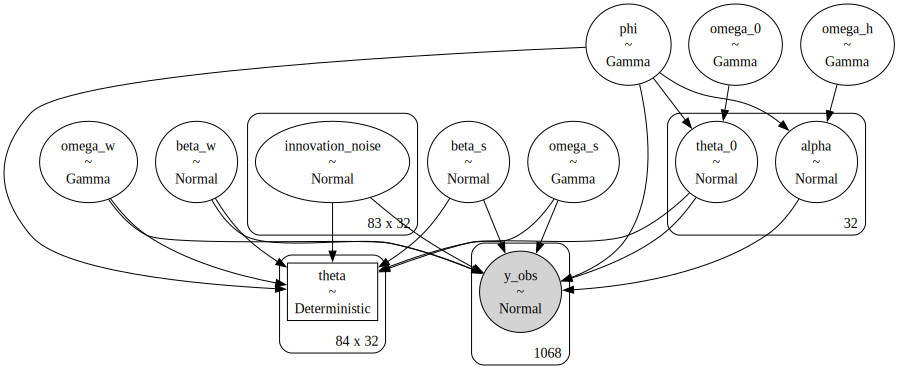

In [4]:
pm.model_to_graphviz(train_model)

In [5]:
initvals = [
    {
        "omega_w": 10.0,
        "omega_s": 1.0,
        "omega_0": 0.5,
        "omega_h": 100.0,
        "beta_w": 0.6,
        "beta_s": 0.5,
    },
    {
        "omega_w": 100.0,
        "omega_s": 20.0,
        "omega_0": 5.0,
        "omega_h": 20.0,
        "beta_w": 0.8,
        "beta_s": 0.8,
    },
    {
        "omega_w": 200.0,
        "omega_s": 80.0,
        "omega_0": 15.0,
        "omega_h": 6.0,
        "beta_w": 0.99,
        "beta_s": 0.98,
    },
    {
        "omega_w": 500.0,
        "omega_s": 200.0,
        "omega_0": 100.0,
        "omega_h": 1.0,
        "beta_w": 1.2,
        "beta_s": 1.2,
    },
    {
        "omega_w": 1000.0,
        "omega_s": 800.0,
        "omega_0": 150.0,
        "omega_h": 0.6,
        "beta_w": 1.8,
        "beta_s": 1.8,
    },
    {
        "omega_w": 1000.0,
        "omega_s": 1.0,
        "omega_0": 150.0,
        "omega_h": 0.3,
        "beta_w": 0.6,
        "beta_s": 1.8,
    },
    {
        "omega_w": 10.0,
        "omega_s": 800.0,
        "omega_0": 0.5,
        "omega_h": 100.0,
        "beta_w": 1.8,
        "beta_s": 0.6,
    },
]

In [6]:
with train_model:
    trace = pm.sample(
        draws=1000,
        tune=17000,
        chains=7,
        cores=7,
        initvals=initvals,
        target_accept=0.95,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (7 chains in 7 jobs)
NUTS: [phi, omega_s, omega_w, beta_s, beta_w, omega_h, omega_0, alpha, theta_0, innovation_noise]


Output()

Sampling 7 chains for 17_000 tune and 1_000 draw iterations (119_000 + 7_000 draws total) took 1896 seconds.


In [46]:
trace.sample_stats.diverging.sum().values

array(0)

<Axes: >

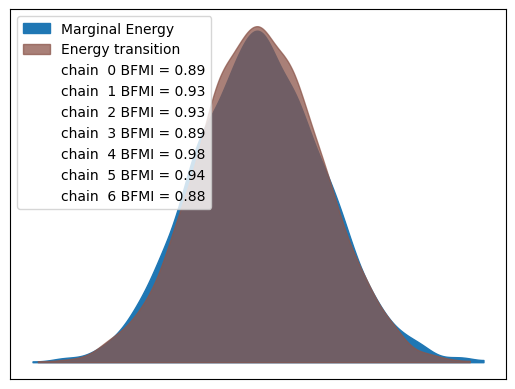

In [49]:
az.plot_energy(trace)

In [50]:
az.summary(trace, var_names=["phi", "omega_w", "omega_s", "omega_0", "omega_h", "beta_w", "beta_s", "alpha"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi,0.01,0.00,0.01,0.01,0.00,0.00,6251.58,5427.63,1.00
omega_w,138.82,75.94,38.14,273.94,1.69,1.86,1762.28,3178.29,1.01
omega_s,25.02,20.17,5.11,59.65,0.39,0.64,2432.86,4420.12,1.00
omega_0,7.61,4.06,1.97,14.65,0.08,0.08,2406.63,4141.79,1.00
omega_h,28.37,13.09,8.88,52.02,0.23,0.23,3097.46,4644.28,1.00
beta_w,0.99,0.02,0.96,1.02,0.00,0.00,2437.21,3378.05,1.00
beta_s,0.62,0.19,0.28,0.99,0.00,0.00,2540.99,4075.18,1.00
alpha[0],2.86,1.95,-1.08,6.34,0.02,0.03,16577.62,5347.20,1.00
alpha[1],5.14,2.04,1.40,9.10,0.02,0.03,12353.80,5262.41,1.00
alpha[2],1.92,1.93,-1.95,5.37,0.02,0.03,15122.82,5499.42,1.00


In [51]:
az.summary(trace.posterior["theta"].isel(theta_dim_0=-1))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],-1.873,4.251,-9.459,6.404,0.041,0.050,10827.0,6052.0,1.0
theta[1],2.267,4.318,-6.160,10.011,0.044,0.048,9857.0,6095.0,1.0
theta[2],1.436,3.986,-6.318,8.475,0.039,0.042,10188.0,6317.0,1.0
theta[3],-5.871,4.477,-14.156,2.670,0.047,0.048,9187.0,5838.0,1.0
theta[4],0.743,4.099,-6.924,8.375,0.041,0.041,10175.0,6105.0,1.0
theta[5],-3.000,4.244,-11.373,4.654,0.040,0.044,11495.0,6576.0,1.0
theta[6],1.507,3.953,-5.856,8.983,0.044,0.043,7933.0,5901.0,1.0
theta[7],-0.376,4.038,-8.200,7.105,0.039,0.046,10489.0,5800.0,1.0
theta[8],5.212,4.075,-2.358,12.988,0.040,0.046,10554.0,5712.0,1.0
theta[9],5.002,4.177,-2.971,12.866,0.046,0.046,8183.0,5883.0,1.0


array([[<Axes: title={'center': 'omega_w'}>,
        <Axes: title={'center': 'omega_w'}>],
       [<Axes: title={'center': 'omega_s'}>,
        <Axes: title={'center': 'omega_s'}>]], dtype=object)

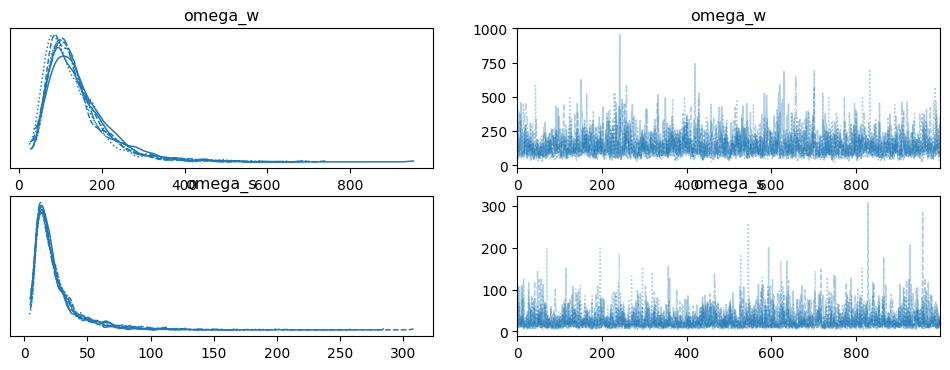

In [60]:
az.plot_trace(trace, var_names=["omega_w", "omega_s"])

In [88]:
trace.to_netcdf("state_space.nc")

'state_space.nc'

# Prediction Model

In [176]:
posterior_means = {
    "phi": trace.posterior["phi"].mean().values,
    "omega_s": trace.posterior["omega_s"].mean().values,
    "omega_w": trace.posterior["omega_w"].mean().values,
    "beta_s": trace.posterior["beta_s"].mean().values,
    "beta_w": trace.posterior["beta_w"].mean().values,
    "omega_h": trace.posterior["omega_h"].mean().values,
    "omega_0": trace.posterior["omega_0"].mean().values,
    "theta_0": trace.posterior["theta_0"].mean(dim=["chain", "draw"]).values,
    "alpha": trace.posterior["alpha"].mean(dim=["chain", "draw"]).values,
    "theta": trace.posterior["theta"].mean(dim=["chain", "draw"]).values,
}

In [177]:
cumulative_data = data[data["season"] < TEST_SEASON]
test_data = data[data["season"] == TEST_SEASON]

In [178]:
def build_update_model(cumulative_data, posterior_means):
    # Rebuild week_data, x_mats, y_obs for cumulative_data
    num_seasons = cumulative_data["season_idx"].max() + 1
    week_data = []
    for season in range(num_seasons):
        season_sub_df = cumulative_data[cumulative_data["season_idx"] == season]
        for week in range(num_weeks):
            week_sub_df = season_sub_df[season_sub_df["week_idx"] == week]
            if len(week_sub_df) > 0:
                week_data.append(week_sub_df)

    num_steps = len(week_data)
    week_idx = np.array([wd["week_idx"].iloc[0] for wd in week_data])
    is_new_season = (week_idx == 0).astype("int32")
    x_mats = [build_design_matrix(wd) for wd in week_data]
    y_obs = [wd["result"].values for wd in week_data]

    with pm.Model() as update_model:
        # Use posterior means as initialization
        phi = pm.Gamma("phi", alpha=0.5, beta=0.5 * 100)
        omega_s = pm.Gamma("omega_s", alpha=0.5, beta=0.5 / 16)
        omega_w = pm.Gamma("omega_w", alpha=0.5, beta=0.5 / 60)
        beta_s = pm.Normal("beta_s", mu=0.98, sigma=1)
        beta_w = pm.Normal("beta_w", mu=0.995, sigma=1)
        omega_h = pm.Gamma("omega_h", alpha=0.5, beta=0.5 / 6)
        omega_zero = pm.Gamma("omega_0", alpha=0.5, beta=0.5 / 6)
        alpha = pm.Normal("alpha", mu=3, sigma=1 / pt.sqrt(omega_h * phi), shape=num_teams)
        theta_init = pm.Normal("theta_0", mu=0, sigma=1 / pt.sqrt(omega_zero * phi), shape=num_teams)
        innovation_noise = pm.Normal("innovation_noise", mu=0, sigma=1, shape=(num_steps - 1, num_teams))

        # State evolution using scan
        def evolve_theta(is_new_season_t, innovation_t, theta_prev, beta_s, beta_w, omega_s, omega_w, phi):
            beta_t = is_new_season_t * beta_s + (1 - is_new_season_t) * beta_w
            omega_t = is_new_season_t * omega_s + (1 - is_new_season_t) * omega_w
            G_theta_prev = theta_prev - pt.mean(theta_prev)
            theta_new = beta_t * G_theta_prev + innovation_t / pt.sqrt(omega_t * phi)
            return theta_new
        
        is_new_season_pt = pt.as_tensor(is_new_season[1:]) # Skip first timestep (use theta_init)
        theta_sequence, _ = scan(
            fn=evolve_theta,
            sequences=[is_new_season_pt, innovation_noise],
            outputs_info=[theta_init],
            non_sequences=[beta_s, beta_w, omega_s, omega_w, phi],
        )

        # Concatenate initial theta with evolved sequence
        all_theta = pt.concatenate([theta_init[None, :], theta_sequence], axis=0)
        pm.Deterministic("theta", all_theta)

        # Stack all design matrices and observations
        max_games = max(x.shape[0] for x in x_mats)

        # Pad design matrices and observations to same length
        X_padded = []
        y_padded = []
        mask = []
        
        for x, y in zip(x_mats, y_obs):
            n_games = x.shape[0]
            if n_games < max_games:
                x_pad = np.vstack([x, np.zeros((max_games - n_games, 64))])
                y_pad = np.concatenate([y, np.zeros(max_games - n_games)])
                m = np.concatenate([np.ones(n_games), np.zeros(max_games - n_games)])
            else:
                x_pad = x
                y_pad = y
                m = np.ones(n_games)
            X_padded.append(x_pad)
            y_padded.append(y_pad)
            mask.append(m)
        
        X_all = np.array(X_padded)  # Shape: (num_steps, max_games, 64)
        y_all = np.array(y_padded)  # Shape: (num_steps, max_games)
        mask_all = np.array(mask)   # Shape: (num_steps, max_games)

        # Combine theta and alpha for prediction
        theta_expanded = pt.concatenate([all_theta, pt.tile(alpha, (num_steps, 1))], axis=1)
        
        # Compute predictions: X_all @ theta_expanded.T, then take diagonal
        mu_all = pt.batched_dot(X_all, theta_expanded[:, :, None])[:, :, 0]    
        sigma_step = 1 / pm.math.sqrt(phi)
        
        # Likelihood with mask
        pm.Normal(
            "y_obs",
            mu=mu_all[mask_all == 1],
            sigma=sigma_step,
            observed=y_all[mask_all == 1]
        )

    return update_model, x_mats, y_obs, week_data

In [179]:
def predict_week(week_games, posterior_means, is_first_week):
    predictions = []
    
    current_theta = posterior_means["theta"][-1]
    if is_first_week:
        beta = posterior_means["beta_s"]
    else:
        beta = posterior_means["beta_w"]
    G = current_theta - np.mean(current_theta)
    next_theta = beta * G
    alpha = posterior_means["alpha"]
    
    for _, game in week_games.iterrows():
        home_idx = int(game["home_idx"])
        away_idx = int(game["away_idx"])
        predicted_margin = (
            next_theta[home_idx] - 
            next_theta[away_idx] + 
            alpha[home_idx]
        )
        predictions.append({
            "home_team": game["home_team"],
            "away_team": game["away_team"],
            "prediction": predicted_margin,
            "result": game["result"],
            "week": game["week"]
        })
    
    return pd.DataFrame(predictions)

In [180]:
predictions = []
current_posterior_means = posterior_means.copy()

for week in range(num_weeks):
    print(f"\n=== Week {week} ===")
    
    # Check if this is the first week of the season
    is_first_week = (week == 0)
    
    # 1. Make predictions for this week BEFORE adding results
    next_week_games = test_data[test_data["week_idx"] == week]
    week_predictions = predict_week(next_week_games, current_posterior_means, is_first_week)
    predictions.append(week_predictions)
    
    # 2. Add this week's results to cumulative data
    cumulative_data = pd.concat([cumulative_data, next_week_games])
    
    # 3. Rebuild and refit model with updated data
    update_model, _, _, _ = build_update_model(cumulative_data, current_posterior_means)
    
    with update_model:
        update_trace = pm.sample(
            draws=1000,
            tune=4000,
            chains=2,
            cores=2,
            initvals=current_posterior_means,
            target_accept=0.95,
            return_inferencedata=True
        )
    
    # 4. Update posterior means for next iteration
    current_posterior_means = {
        "phi": update_trace.posterior["phi"].mean().values,
        "omega_s": update_trace.posterior["omega_s"].mean().values,
        "omega_w": update_trace.posterior["omega_w"].mean().values,
        "beta_s": update_trace.posterior["beta_s"].mean().values,
        "beta_w": update_trace.posterior["beta_w"].mean().values,
        "omega_h": update_trace.posterior["omega_h"].mean().values,
        "omega_0": update_trace.posterior["omega_0"].mean().values,
        "theta_0": update_trace.posterior["theta_0"].mean(dim=["chain", "draw"]).values,
        "alpha": update_trace.posterior["alpha"].mean(dim=["chain", "draw"]).values,
        "theta": update_trace.posterior["theta"].mean(dim=["chain", "draw"]).values,
    }


=== Week 0 ===


c:\Users\iggysiegel\miniconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [phi, omega_s, omega_w, beta_s, beta_w, omega_h, omega_0, alpha, theta_0, innovation_noise]


Output()

Sampling 2 chains for 4_000 tune and 1_000 draw iterations (8_000 + 2_000 draws total) took 327 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



=== Week 1 ===


...

Sampling 2 chains for 4_000 tune and 1_000 draw iterations (8_000 + 2_000 draws total) took 420 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



=== Week 20 ===


c:\Users\iggysiegel\miniconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [phi, omega_s, omega_w, beta_s, beta_w, omega_h, omega_0, alpha, theta_0, innovation_noise]


Output()

Sampling 2 chains for 4_000 tune and 1_000 draw iterations (8_000 + 2_000 draws total) took 482 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
all_predictions = pd.concat(predictions)
all_predictions.to_csv(f"predictions_{TEST_SEASON}.csv", index=False)